In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import set_config

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import LinearRegression

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [ ]:
file_path="/content/insurance.csv"
df=pd.read_csv(file_path)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.shape

(1338, 7)

In [ ]:
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [ ]:
print("========================= Information Regarding Each Column =================================")
df.info()

========================= Information Regarding Each Column =================================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df[df.duplicated(keep=False)]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [ ]:
df=df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(1337, 7)

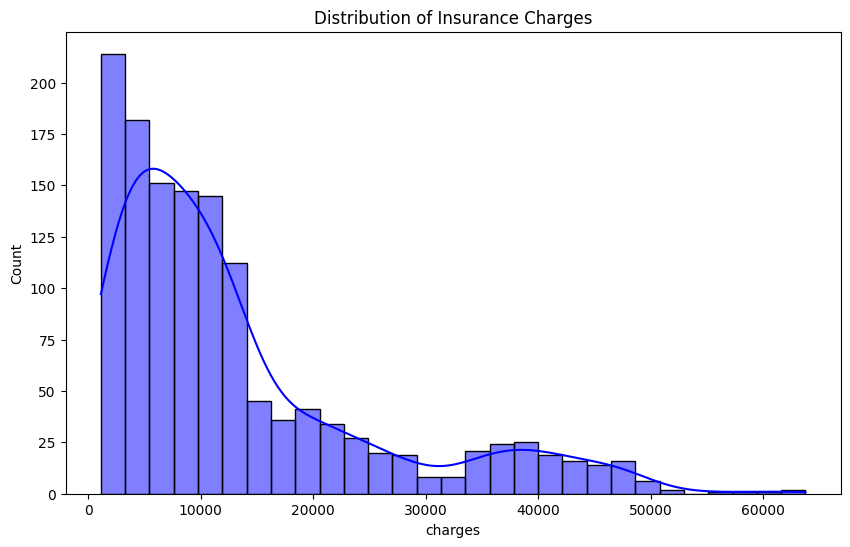

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(data=df,x="charges",kde=True,color="blue")
plt.title("Distribution of Insurance Charges")
plt.show()

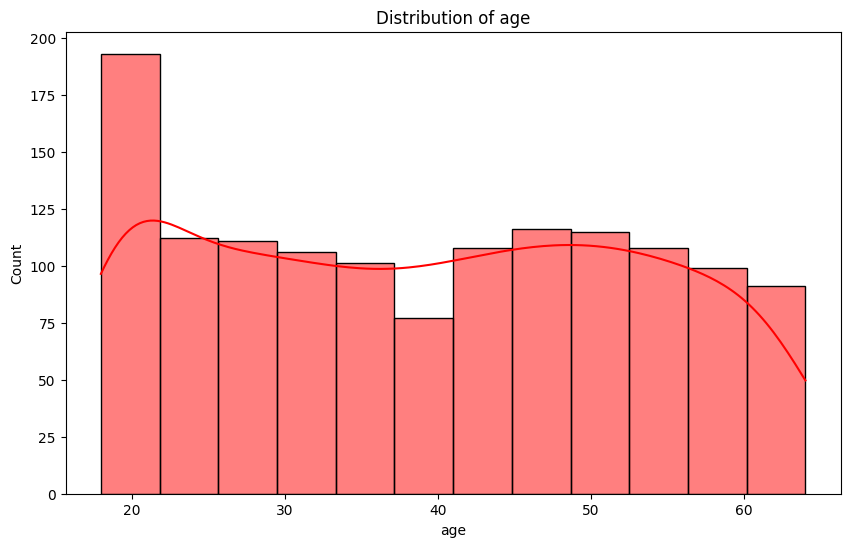

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(data=df,x="age",kde=True,color="red")
plt.title("Distribution of age")
plt.show()

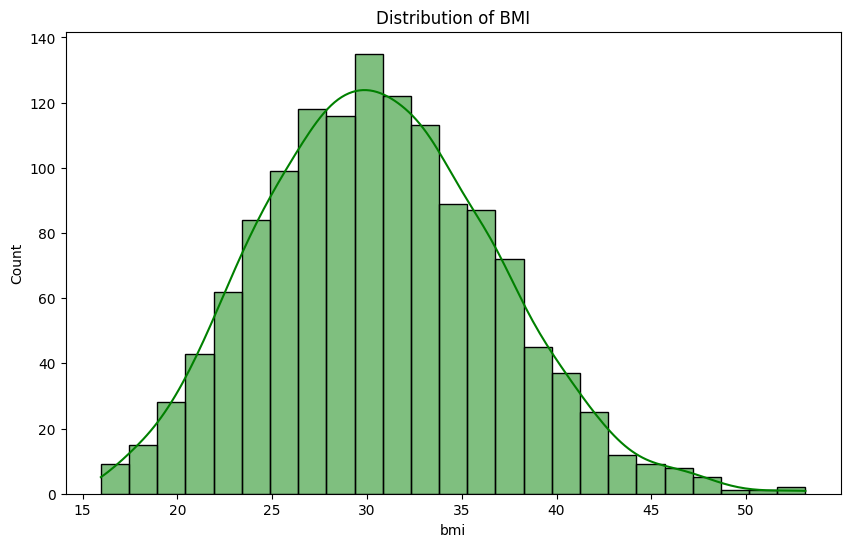

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(data=df,x="bmi",kde=True,color="green")
plt.title("Distribution of BMI")
plt.show()

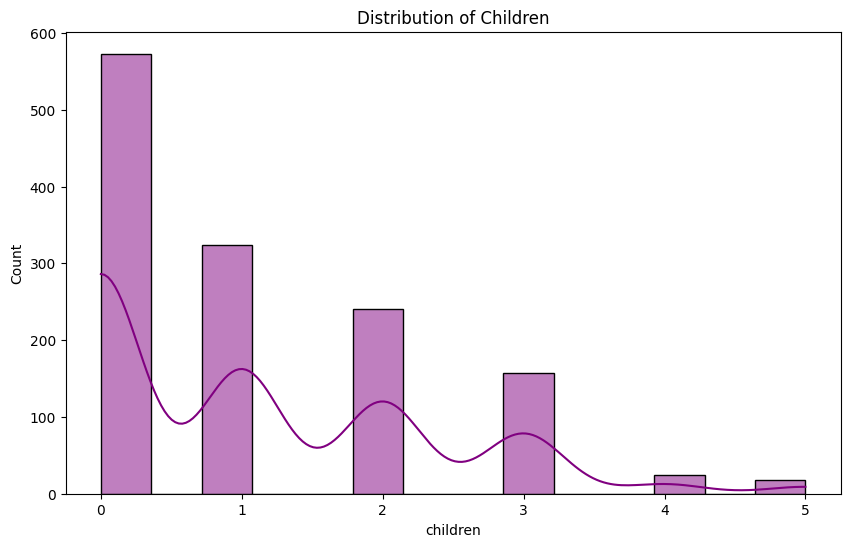

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(data=df,x="children",kde=True,color="purple")
plt.title("Distribution of Children")
plt.show()

<Figure size 1000x600 with 0 Axes>

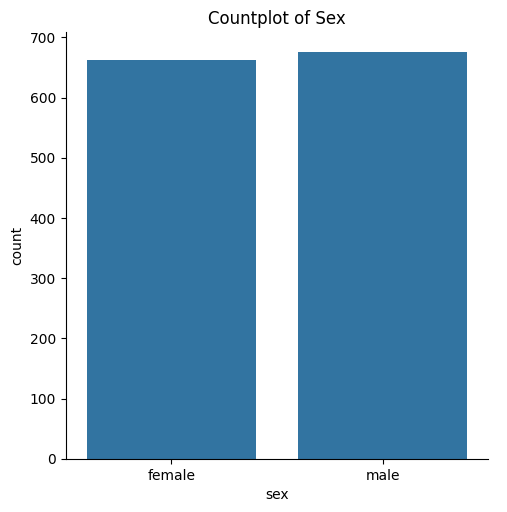

In [ ]:
plt.figure(figsize=(10,6))
sns.catplot(data=df,x="sex",kind="count")
plt.title("Countplot of Sex")
plt.show()

<Figure size 1000x600 with 0 Axes>

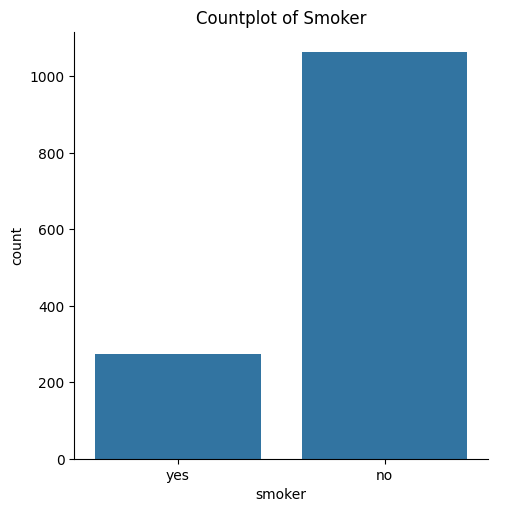

In [ ]:
plt.figure(figsize=(10,6))
sns.catplot(data=df,x="smoker",kind="count")
plt.title("Countplot of Smoker")
plt.show()

<Figure size 1000x600 with 0 Axes>

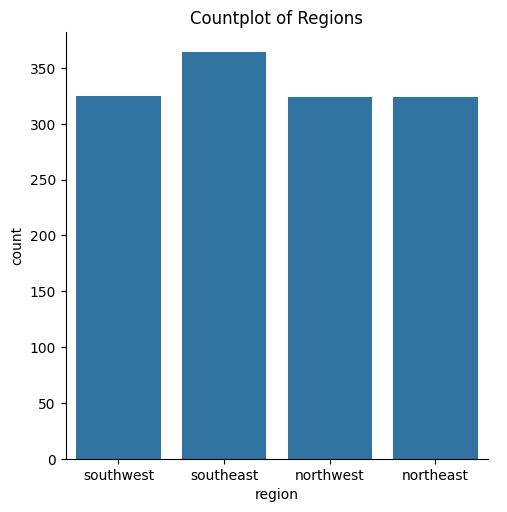

In [ ]:
plt.figure(figsize=(10,6))
sns.catplot(data=df,x="region",kind="count")
plt.title("Countplot of Regions")
plt.show()

In [ ]:
numeric_columns=df.select_dtypes(include='number').columns.to_list()
numeric_columns

['age', 'bmi', 'children', 'charges']

In [ ]:
df[numeric_columns].skew()

,0
age,0.054781
bmi,0.283914
children,0.937421
charges,1.515391


In [ ]:
df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109344,0.041536,0.298308
bmi,0.109344,1.000000,0.012755,0.198401
children,0.041536,0.012755,1.000000,0.067389
charges,0.298308,0.198401,0.067389,1.000000


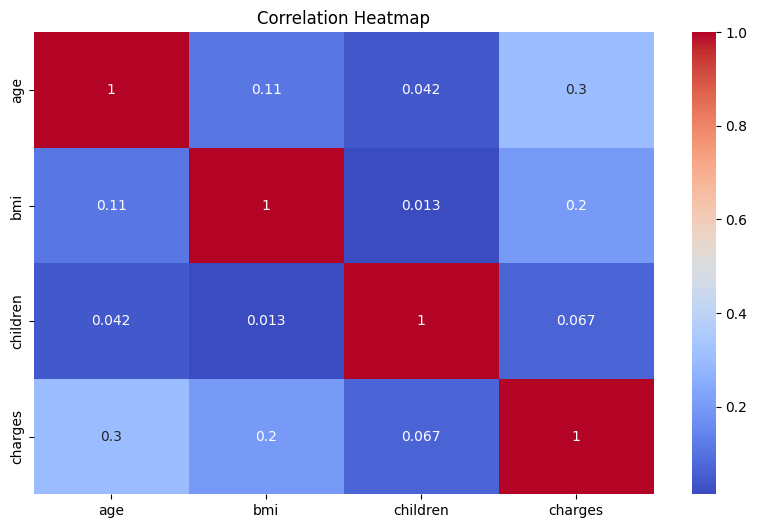

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(data=df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

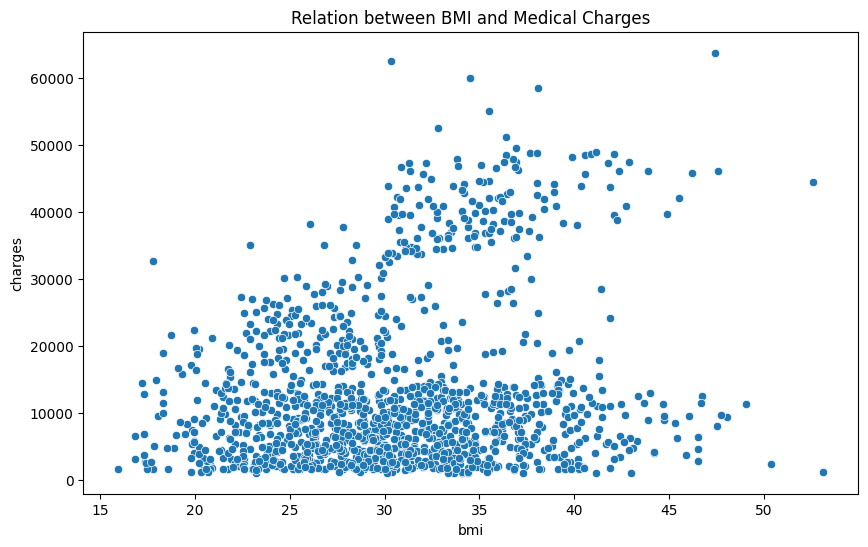

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x="bmi",y="charges")
plt.title("Relation between BMI and Medical Charges")
plt.show()

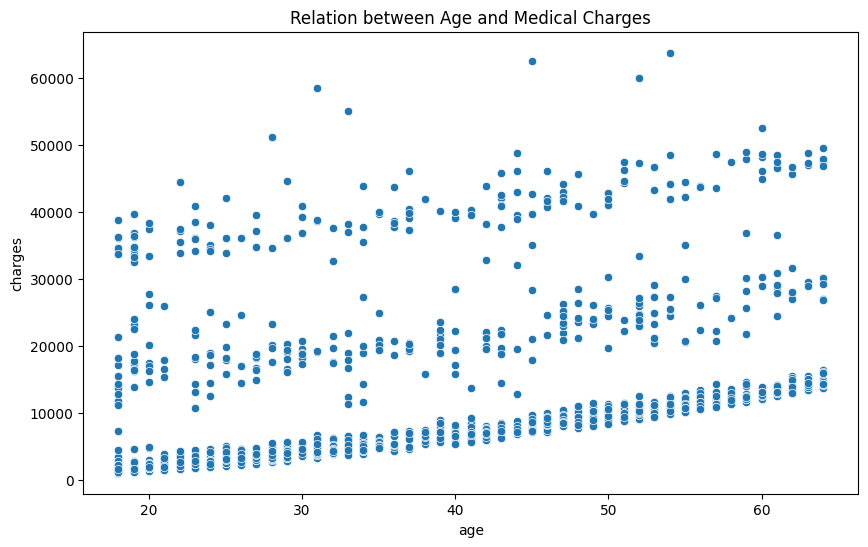

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x="age",y="charges")
plt.title("Relation between Age and Medical Charges")
plt.show()

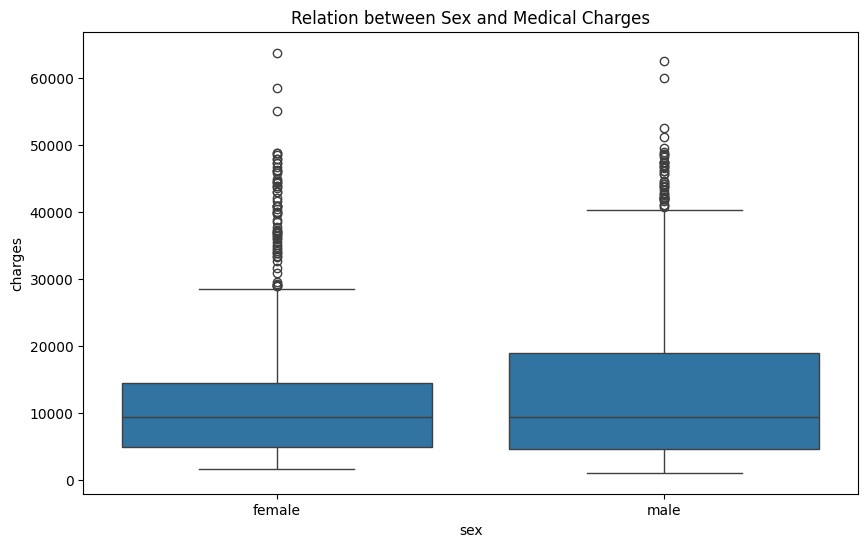

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x="sex",y="charges")
plt.title("Relation between Sex and Medical Charges")
plt.show()

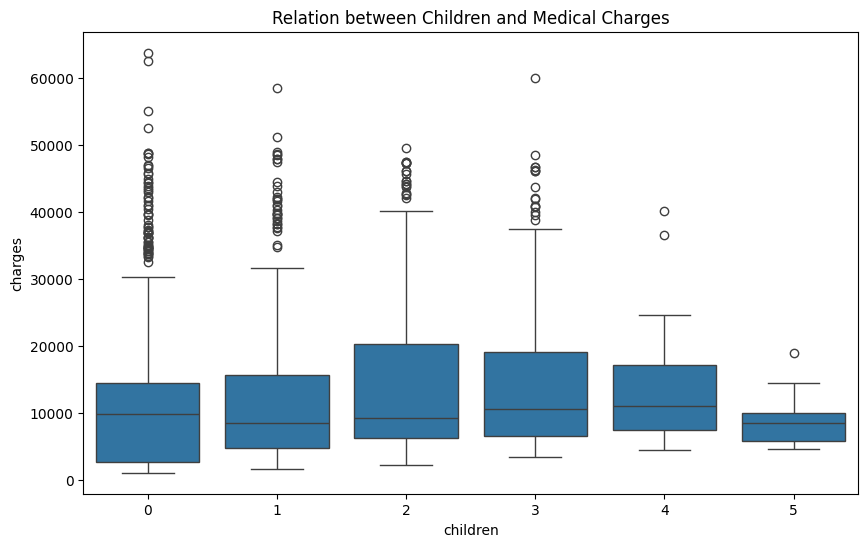

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x="children",y="charges")
plt.title("Relation between Children and Medical Charges")
plt.show()

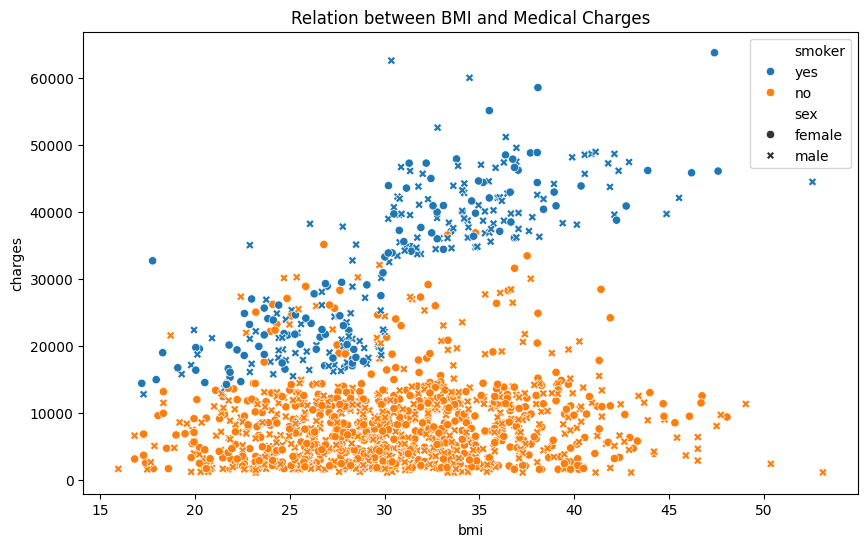

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x="bmi",y="charges",hue="smoker",style="sex")
plt.title("Relation between BMI and Medical Charges")
plt.show()

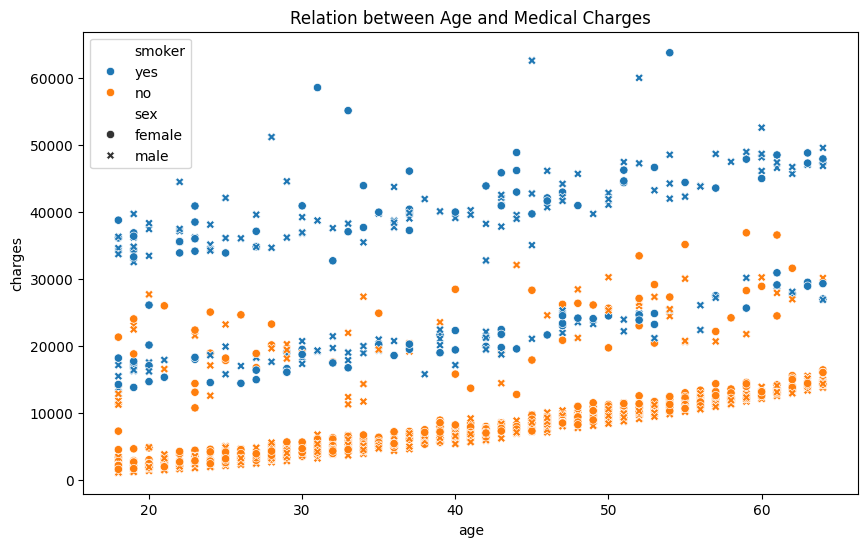

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x="age",y="charges",hue="smoker",style="sex")
plt.title("Relation between Age and Medical Charges")
plt.show()

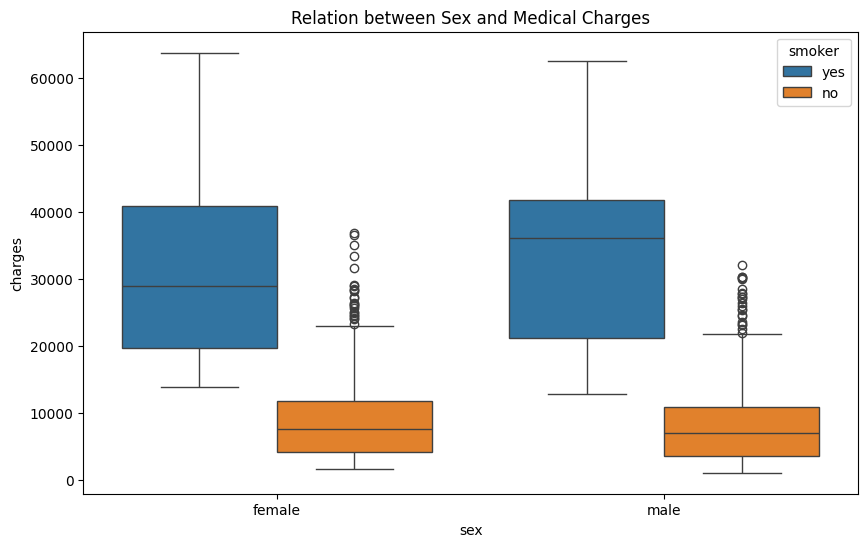

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x="sex",y="charges",hue="smoker")
plt.title("Relation between Sex and Medical Charges")
plt.show()

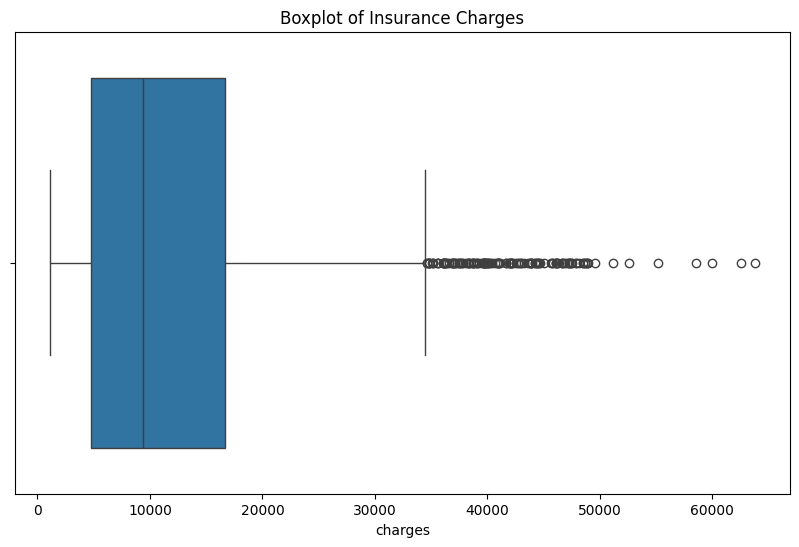

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x="charges")
plt.title("Boxplot of Insurance Charges")
plt.show()

In [ ]:
Q1=df["charges"].quantile(0.25)
Q3=df["charges"].quantile(0.75)
IQR=Q3-Q1
upper_bound=Q3+1.5*IQR
df[df["charges"]>upper_bound].shape[0]/df.shape[0]*100

10.396409872849663

In [ ]:
print(Q1)
print(Q3)
print(IQR)
print(upper_bound)

4746.344
16657.71745
11911.37345
34524.777625


In [ ]:
df["charges"]=np.log1p(df["charges"])

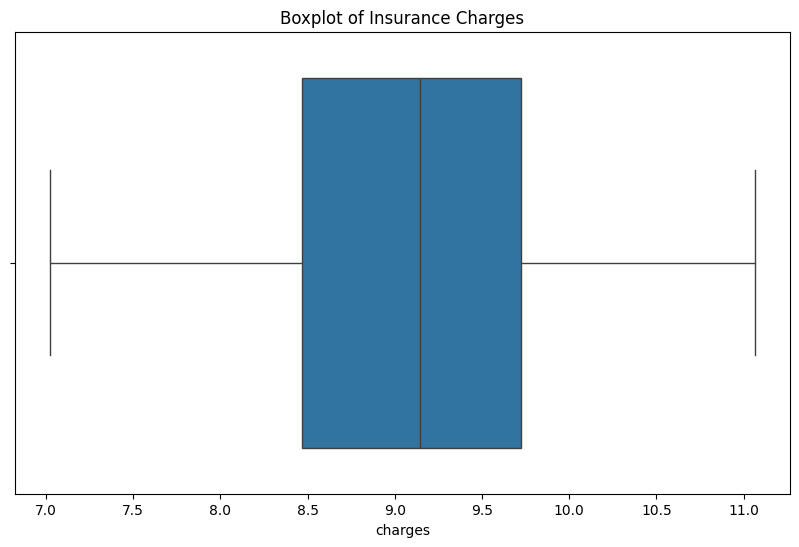

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x="charges")
plt.title("Boxplot of Insurance Charges")
plt.show()

In [ ]:
df[df["charges"]>upper_bound].shape[0]/df.shape[0]*100

0.0

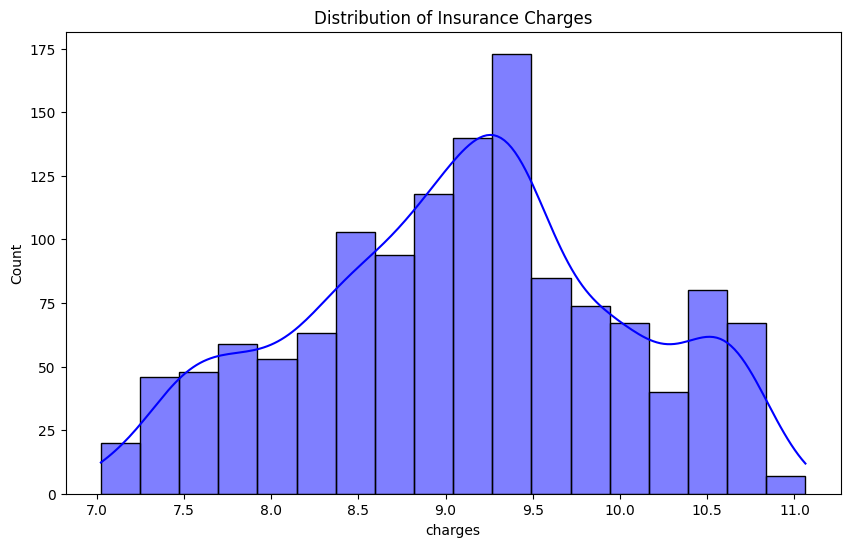

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(data=df,x="charges",kde=True,color="blue")
plt.title("Distribution of Insurance Charges")
plt.show()

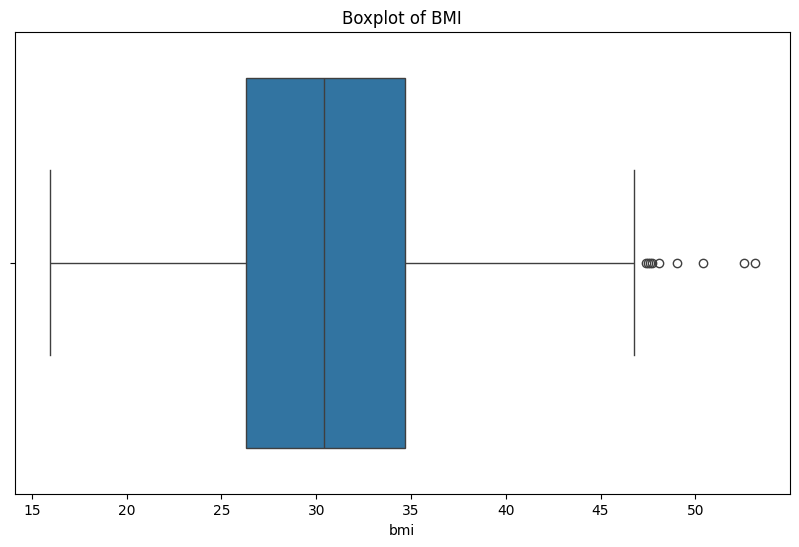

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x="bmi")
plt.title("Boxplot of BMI")
plt.show()

In [ ]:
Q1=df["bmi"].quantile(0.25)
Q3=df["bmi"].quantile(0.75)
IQR=Q3-Q1
upper_bound=Q3+1.5*IQR
len(df[df["bmi"]>upper_bound])

9

In [ ]:
df[df["bmi"]>upper_bound].shape[0]/df.shape[0]*100

0.6731488406881078

In [ ]:
df["bmi"]=np.where(df["bmi"]>upper_bound,upper_bound,df["bmi"])

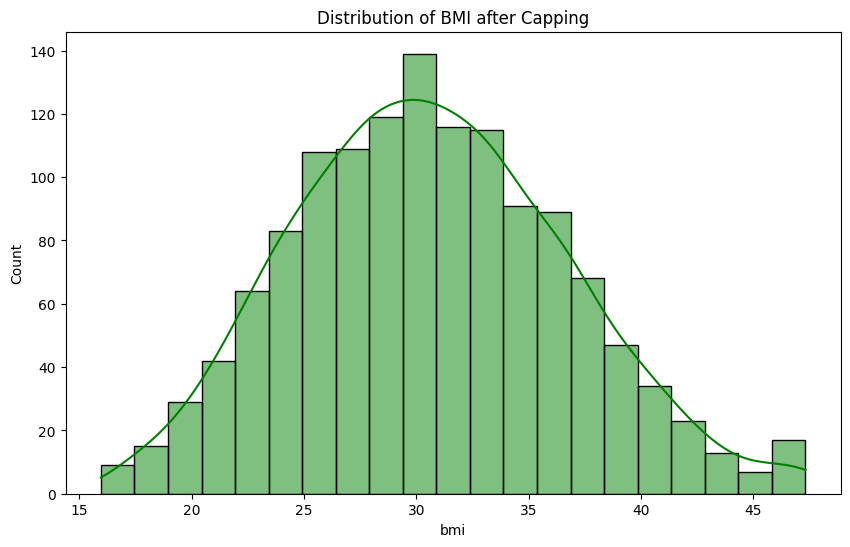

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(data=df,x="bmi",kde=True,color="green")
plt.title("Distribution of BMI after Capping")
plt.show()

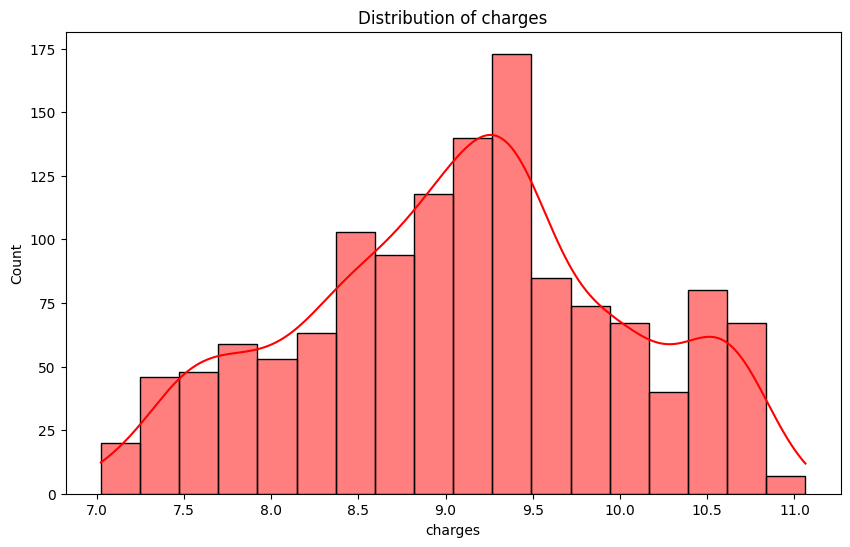

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(data=df,x="charges",kde=True,color="red")
plt.title("Distribution of charges")
plt.show()

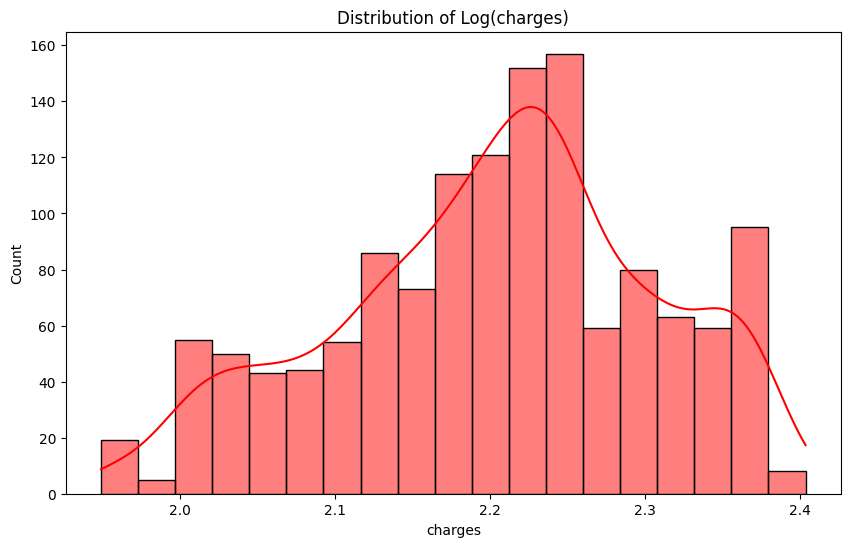

In [ ]:
plt.figure(figsize=(10,6))
# Application du log directement sur la série de données
sns.histplot(x=np.log(df["charges"]), kde=True, color="red")
plt.title("Distribution of Log(charges)")
plt.show()

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(df.drop(columns=["charges"],axis=1),df["charges"],test_size=0.2,random_state=42)

print(X_train.shape[0])
print(X_test.shape[0])
print(y_train.shape[0])
print(y_test.shape[0])

1069
268
1069
268


In [ ]:
categorical_columns=df.select_dtypes(include=["object"]).columns.to_list()
numerical_columns=df.select_dtypes(include=["number"]).columns.to_list()
numerical_columns.remove("charges")
preprocessor = ColumnTransformer(
    transformers=[
        ("encoder", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), categorical_columns),
        ("scaler",  StandardScaler(), numerical_columns)
    ]
)

In [ ]:
LR=LinearRegression()
pipeline=Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        ("model",LR)
    ]
)

In [ ]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['sex', 'smoker', 'region']),
                                                 ('scaler', StandardScaler(),
                                                  ['age', 'bmi',
                                                   'children'])])),
                ('model', LinearRegression())])

In [ ]:
y_pred=pipeline.predict(X_test)
r2 = r2_score(y_test, y_pred)

print(f"R-squared Score: {r2:.4f}")

R-squared Score: 0.8295


In [ ]:
cv_score=cross_val_score(pipeline,X_train,y_train,cv=5,scoring="r2")
mae=mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test, y_pred)
trained_model=pipeline.named_steps["model"]
coefficients=trained_model.coef_
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

coef_df['Absolute_Importance'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Absolute_Importance', ascending=False).drop(columns=['Absolute_Importance'])
print("================= Model Performance ========================\n")

print(f"The Cross Validation Score is : {np.mean(cv_score):.4f}")
print(f"The Mean Absolute Error is : {mae: .4f}")
print(f"The Mean Squared Error is : {mse: .4f}")

print("\n================== Top Feature by Coefficient ======================")
print(coef_df)

================= Model Performance ========================

The Cross Validation Score is : 0.7465
The Mean Absolute Error is :  0.2610
The Mean Squared Error is :  0.1582

================== Top Feature by Coefficient ======================
                     Feature  Coefficient
1        encoder__smoker_yes     1.537491
5                scaler__age     0.475233
3  encoder__region_southeast    -0.128763
7           scaler__children     0.118309
4  encoder__region_southwest    -0.101547
6                scaler__bmi     0.080210
0          encoder__sex_male    -0.076513
2  encoder__region_northwest    -0.043739


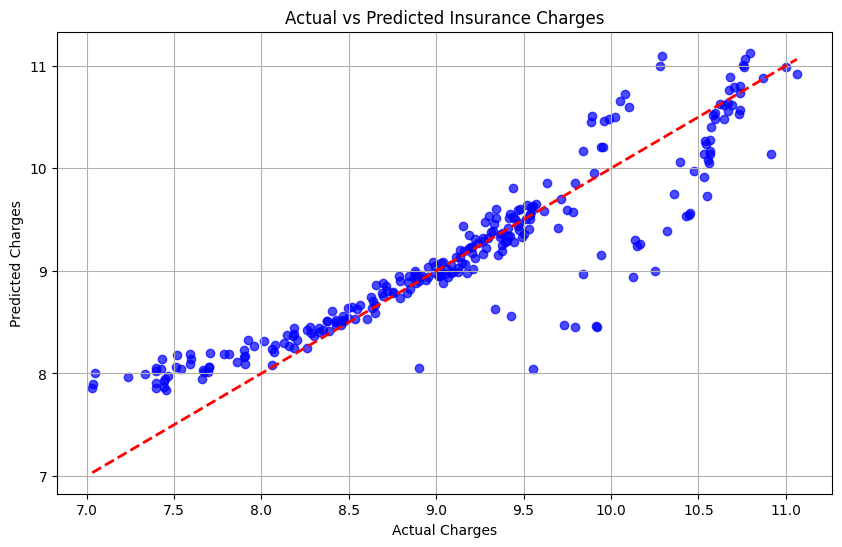

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Insurance Charges')
plt.grid(True)
plt.show()

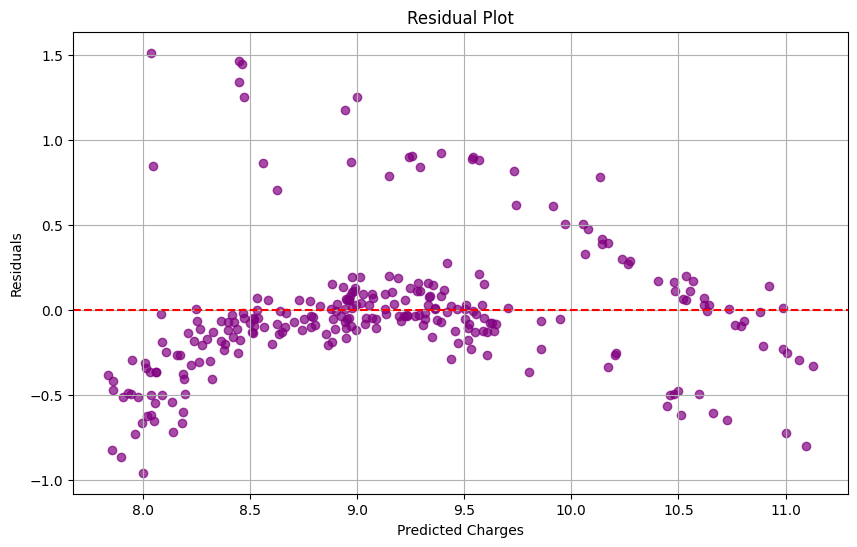

In [ ]:
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.7, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Charges')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True)
plt.show()

In [ ]:
new_member = {
    'age': [35],
    'sex': ['male'],
    'bmi': [27.5],
    'children': [2],
    'smoker': ['no'],
    'region': ['northwest']
}

new_member_df = pd.DataFrame(new_member)

log_predicted_charge = pipeline.predict(new_member_df)

final_predicted_charge = np.expm1(log_predicted_charge)

print(f"Predicted Medical Insurance Charge: ${final_predicted_charge[0]:,.2f}")

Predicted Medical Insurance Charge: $5,891.04


In [ ]:
print(df.groupby('smoker')['charges'].max())

smoker
no     10.516281
yes    11.063061
Name: charges, dtype: float64
